# Linear Discriminant Analysis (LDA) — Wine Quality
Ce notebook charge le jeu de données Wine Quality, binarise la variable `quality` (good vs not good),
et entraîne une pipeline LDA avec séparation train / validation / test (70/15/15).
Il affiche les métriques, la matrice de confusion et la courbe ROC.

In [1]:
# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [6]:
# Load the dataset from workspace
import os
# Workspace root is D:\100DaysofML
csv_path = r'D:\100DaysofML\Notebooks\007_Softmax_Regression\WineQT.csv'
print('Loading CSV from:', csv_path)
df = pd.read_csv(csv_path)
print('Loaded successfully! Shape:', df.shape)
df.head()

Loading CSV from: D:\100DaysofML\Notebooks\007_Softmax_Regression\WineQT.csv
Loaded successfully! Shape: (1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [26]:
# Quick check of columns and target
print('columns:', df.columns.tolist())
if 'quality' not in df.columns:
    raise ValueError('The dataset does not contain a column named "quality".')

# Binarize quality: good (1) if quality >= 7, else 0
df['good'] = (df['quality'] >= 7).astype(int)

print('\nClass distribution before balancing:')
print(df['good'].value_counts())

# Balance the binarized dataset by upsampling class good (1) to match class bad (0)
df_bad = df[df['good'] == 0]
df_good = df[df['good'] == 1]

if len(df_good) < len(df_bad):
    df_good_bal = df_good.sample(n=len(df_bad), replace=True, random_state=42)
    df_balanced = pd.concat([df_bad, df_good_bal], axis=0)
elif len(df_bad) < len(df_good):
    df_bad_bal = df_bad.sample(n=len(df_good), replace=True, random_state=42)
    df_balanced = pd.concat([df_bad_bal, df_good], axis=0)
else:
    df_balanced = df.copy()

# Shuffle and continue the pipeline on balanced data
df = df_balanced.sample(frac=1.0, random_state=42).reset_index(drop=True)

print('\nClass distribution after balancing:')
print(df['good'].value_counts(normalize=False))
print(df['good'].value_counts(normalize=True))

columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id', 'good']

Class distribution before balancing:
good
0    159
1    159
Name: count, dtype: int64

Class distribution after balancing:
good
1    159
0    159
Name: count, dtype: int64
good
1    0.5
0    0.5
Name: proportion, dtype: float64


In [27]:
# Features and target
X = df.drop(columns=['quality', 'good'], errors='ignore')
y = df['good']
# Train / (val+test) then split temp into val/test to get 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
print('Shapes:')
print('X_train', X_train.shape, 'X_val', X_val.shape, 'X_test', X_test.shape)

Shapes:
X_train (222, 12) X_val (48, 12) X_test (48, 12)


In [28]:
# Optuna hyperparameter search on the training split only
try:
    import optuna
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'optuna'])
    import optuna

from sklearn.model_selection import StratifiedKFold, cross_val_score

# Objective: maximize mean ROC AUC on the training split (5-fold CV)
def objective(trial):
    solver = trial.suggest_categorical('solver', ['svd', 'lsqr', 'eigen'])
    shrinkage = None
    if solver in ('lsqr', 'eigen'):
        shrinkage_choice = trial.suggest_categorical('shrinkage_choice', ['none', 'auto', 'float'])
        if shrinkage_choice == 'float':
            shrinkage = trial.suggest_float('shrinkage', 0.0, 1.0)
        elif shrinkage_choice == 'auto':
            shrinkage = 'auto'
    lda = LinearDiscriminantAnalysis(solver=solver, shrinkage=shrinkage)
    pipe_cv = make_pipeline(StandardScaler(), lda)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipe_cv, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return float(np.mean(scores))

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

best_params = study.best_trial.params
best_solver = best_params['solver']
best_shrink = None
if 'shrinkage' in best_params:
    best_shrink = best_params['shrinkage']
elif best_params.get('shrinkage_choice') == 'auto':
    best_shrink = 'auto'

print('Best trial:')
print(best_params)
print('Best value (mean CV ROC AUC):', study.best_value)

[I 2026-04-30 17:50:02,960] A new study created in memory with name: no-name-5a88918a-ff6e-4ea1-9093-617379199e3d
[I 2026-04-30 17:50:09,731] Trial 0 finished with value: 0.8644448436938557 and parameters: {'solver': 'eigen', 'shrinkage_choice': 'none'}. Best is trial 0 with value: 0.8644448436938557.
[I 2026-04-30 17:50:12,245] Trial 1 finished with value: 0.8644448436938557 and parameters: {'solver': 'svd'}. Best is trial 0 with value: 0.8644448436938557.
[I 2026-04-30 17:50:12,309] Trial 2 finished with value: 0.8730326985267697 and parameters: {'solver': 'eigen', 'shrinkage_choice': 'auto'}. Best is trial 2 with value: 0.8730326985267697.
[I 2026-04-30 17:50:12,353] Trial 3 finished with value: 0.8664570607258353 and parameters: {'solver': 'eigen', 'shrinkage_choice': 'float', 'shrinkage': 0.7708912398472723}. Best is trial 2 with value: 0.8730326985267697.
[I 2026-04-30 17:50:12,395] Trial 4 finished with value: 0.8644448436938557 and parameters: {'solver': 'svd'}. Best is trial 2

Best trial:
{'solver': 'eigen', 'shrinkage_choice': 'auto'}
Best value (mean CV ROC AUC): 0.8730326985267697


Validation Accuracy (best params): 0.6666666666666666

Validation Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.75      0.69        24
           1       0.70      0.58      0.64        24

    accuracy                           0.67        48
   macro avg       0.67      0.67      0.66        48
weighted avg       0.67      0.67      0.66        48



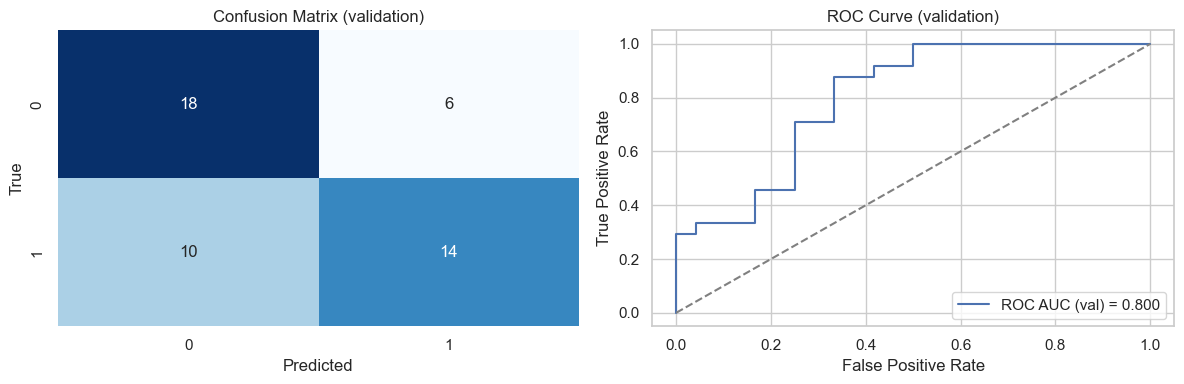

In [29]:
# Validation step with best hyperparameters (train -> val)
import joblib

pipe_best = make_pipeline(
    StandardScaler(),
    LinearDiscriminantAnalysis(solver=best_solver, shrinkage=best_shrink)
)
pipe_best.fit(X_train, y_train)

y_val_pred_best = pipe_best.predict(X_val)
y_val_proba_best = pipe_best.predict_proba(X_val)[:, 1]

print('Validation Accuracy (best params):', accuracy_score(y_val, y_val_pred_best))
print('\nValidation Classification Report:\n', classification_report(y_val, y_val_pred_best))

cm_val = confusion_matrix(y_val, y_val_pred_best)
roc_auc_val = roc_auc_score(y_val, y_val_proba_best)
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_proba_best)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (validation)')

axes[1].plot(fpr_val, tpr_val, label=f'ROC AUC (val) = {roc_auc_val:.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (validation)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

Test Accuracy (final model): 0.7916666666666666

Test Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.79      0.79        24
           1       0.79      0.79      0.79        24

    accuracy                           0.79        48
   macro avg       0.79      0.79      0.79        48
weighted avg       0.79      0.79      0.79        48



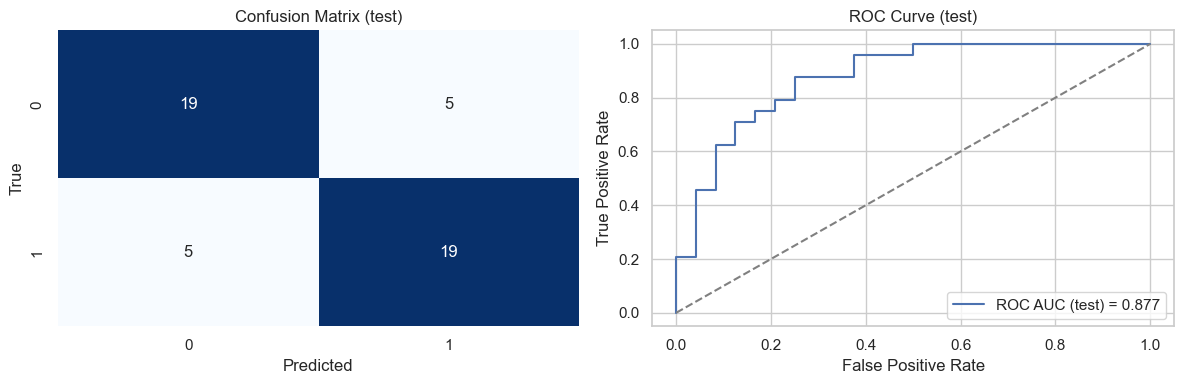

In [30]:
# Final test step (train + val -> test)
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

pipe_final = make_pipeline(
    StandardScaler(),
    LinearDiscriminantAnalysis(solver=best_solver, shrinkage=best_shrink)
)
pipe_final.fit(X_train_full, y_train_full)

y_test_pred = pipe_final.predict(X_test)
y_test_proba = pipe_final.predict_proba(X_test)[:, 1]

print('Test Accuracy (final model):', accuracy_score(y_test, y_test_pred))
print('\nTest Classification Report:\n', classification_report(y_test, y_test_pred))

cm_test = confusion_matrix(y_test, y_test_pred)
roc_auc_test = roc_auc_score(y_test, y_test_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (test)')

axes[1].plot(fpr_test, tpr_test, label=f'ROC AUC (test) = {roc_auc_test:.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (test)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()